In [7]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./sonar/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

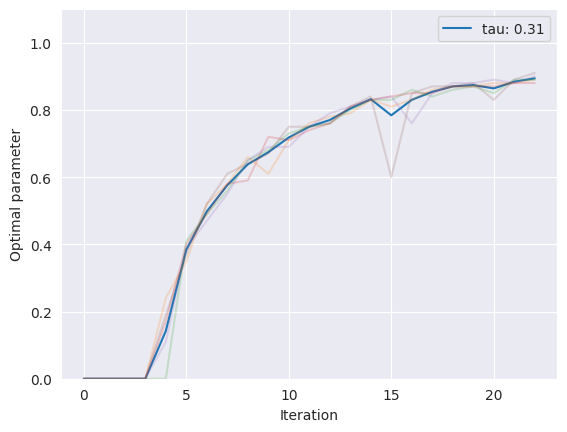

In [8]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'gamma' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)
for idx in list_idx_ar:
    max_before_tempering_is_one = int(jnp.min(jnp.argwhere(PKLs[idx]['res'][6]==1), axis=0)[1])
    plt.plot(np.mean(PKLs[idx]['res'][2], axis=0)[:max_before_tempering_is_one])
    for run in range(PKLs[idx]['res'][0].shape[0]):
        plt.plot(PKLs[idx]['res'][2][run][:max_before_tempering_is_one], alpha=0.2)
plt.ylabel("Optimal parameter")
plt.xlabel("Iteration")
plt.ylim(0, 1.1)
plt.legend()
plt.savefig("AR_optimal_parameter.png")


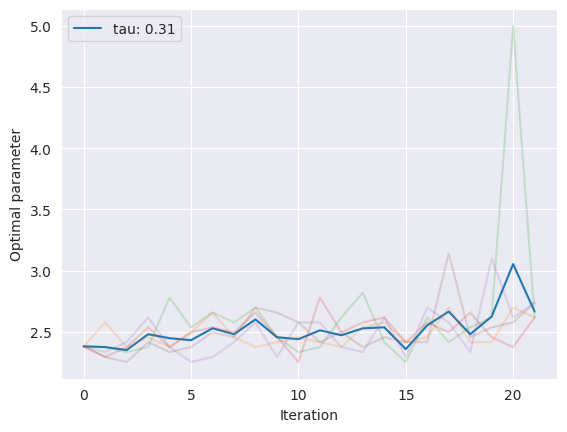

In [9]:
for idx in list_idx_rwmh:
    max_before_tempering_is_one = int(jnp.min(jnp.argwhere(PKLs[idx]['res'][6]==1), axis=0)[1])
    plt.plot(np.mean(PKLs[idx]['res'][2], axis=0)[:max_before_tempering_is_one])
    for run in range(PKLs[idx]['res'][0].shape[0]):
        plt.plot(PKLs[idx]['res'][2][run][:max_before_tempering_is_one], alpha=0.2)
plt.ylabel("Optimal parameter")
plt.xlabel("Iteration")
plt.legend()
plt.savefig("RW_optimal_parameter.png")